# 03 — Returns and Discount Factor
**Week 3 | RL Fundamentals**

The **return** G_t is the cumulative reward from time t onwards:

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$

The discount factor γ ∈ [0,1) controls how much the agent cares about future rewards.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Computing Returns

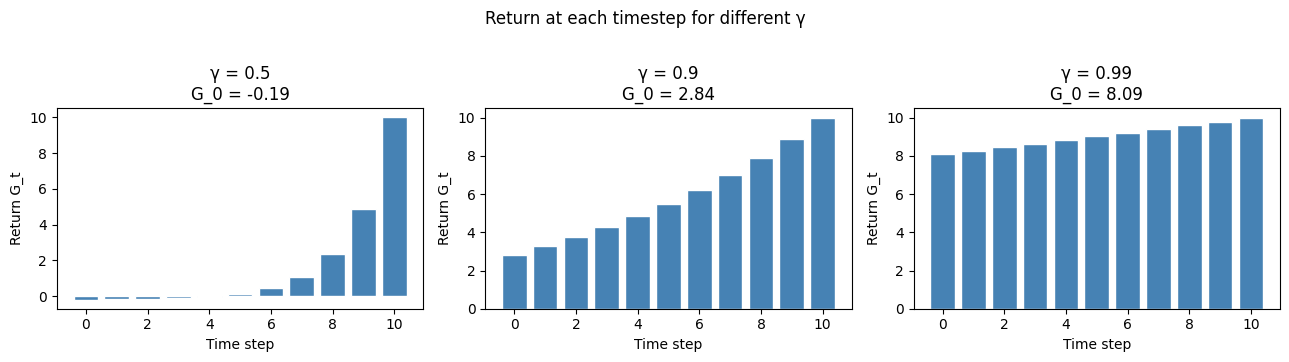

In [2]:
def compute_returns(rewards, gamma):
    """Compute discounted returns for a list of rewards (backwards pass)."""
    G = np.zeros(len(rewards))
    running = 0.0
    for t in reversed(range(len(rewards))):
        running = rewards[t] + gamma * running
        G[t] = running
    return G

# Example trajectory: -0.1 per step, +10 at end
rewards = [-0.1] * 10 + [10.0]
t = np.arange(len(rewards))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, gamma in zip(axes, [0.5, 0.9, 0.99]):
    G = compute_returns(rewards, gamma)
    ax.bar(t, G, color='steelblue', edgecolor='white')
    ax.set_title(f'γ = {gamma}\nG_0 = {G[0]:.2f}')
    ax.set_xlabel('Time step'); ax.set_ylabel('Return G_t')
plt.suptitle('Return at each timestep for different γ', y=1.02)
plt.tight_layout(); plt.show()

## 2. Effect of γ on Discount Weights

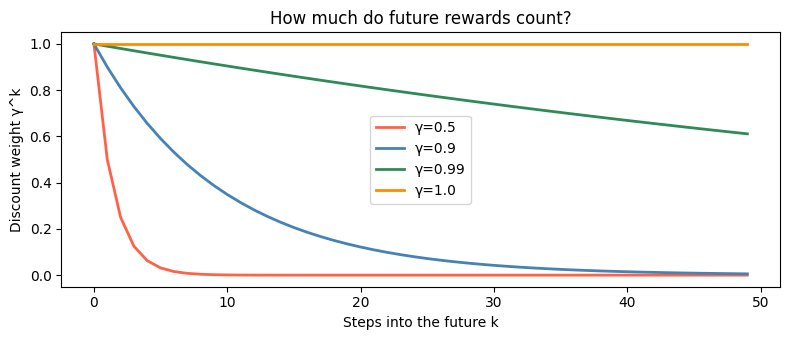


A reward 20 steps away is worth:
  γ=0.5: 0.0000 of its face value
  γ=0.9: 0.1216 of its face value
  γ=0.99: 0.8179 of its face value
  γ=1.0: 1.0000 of its face value


In [3]:
steps = np.arange(0, 50)
fig, ax = plt.subplots(figsize=(8, 3.5))
for gamma, color in [(0.5,'tomato'),(0.9,'steelblue'),(0.99,'seagreen'),(1.0,'darkorange')]:
    weights = gamma ** steps
    ax.plot(steps, weights, label=f'γ={gamma}', linewidth=2, color=color)
ax.set_xlabel('Steps into the future k')
ax.set_ylabel('Discount weight γ^k')
ax.set_title('How much do future rewards count?')
ax.legend(); plt.tight_layout(); plt.show()
print("\nA reward 20 steps away is worth:")
for g in [0.5, 0.9, 0.99, 1.0]:
    print(f"  γ={g}: {g**20:.4f} of its face value")

## 3. Episodic vs Continuing Tasks

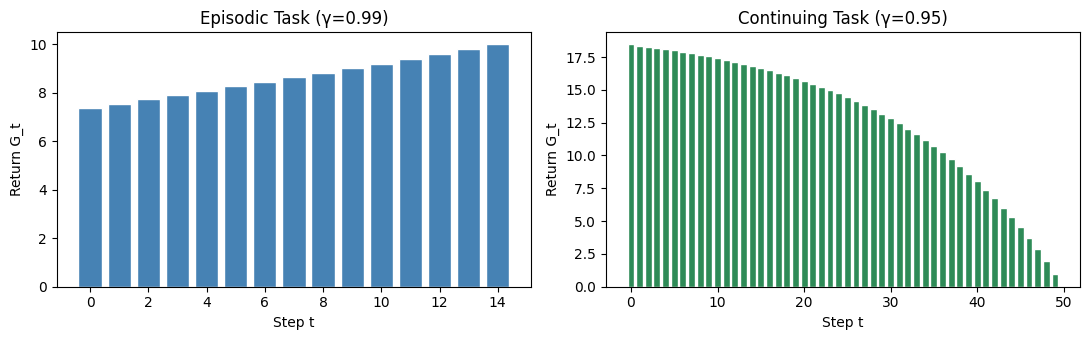

Continuing task: geometric series limit = R/(1-γ) = 20.0
Empirical G_0 = 18.46


In [4]:
# Episodic: trajectory has a natural end (e.g. reaching the goal)
def episodic_returns(n_steps=15, goal_reward=10.0, step_cost=-0.1, gamma=0.99):
    rewards = [step_cost] * (n_steps-1) + [goal_reward]
    return compute_returns(rewards, gamma)

# Continuing: no terminal state; must use discounting to keep G finite
def continuing_returns(n_steps=50, reward_per_step=1.0, gamma=0.95):
    rewards = [reward_per_step] * n_steps
    return compute_returns(rewards, gamma)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
g_ep = episodic_returns()
axes[0].bar(range(len(g_ep)), g_ep, color='steelblue', edgecolor='white')
axes[0].set_title('Episodic Task (γ=0.99)')
axes[0].set_xlabel('Step t'); axes[0].set_ylabel('Return G_t')

g_cont = continuing_returns()
axes[1].bar(range(len(g_cont)), g_cont, color='seagreen', edgecolor='white')
axes[1].set_title('Continuing Task (γ=0.95)')
axes[1].set_xlabel('Step t'); axes[1].set_ylabel('Return G_t')
plt.tight_layout(); plt.show()

print(f"Continuing task: geometric series limit = R/(1-γ) = {1.0/(1-0.95):.1f}")
print(f"Empirical G_0 = {g_cont[0]:.2f}")

## 4. The Bellman Equation for Returns
G_t = R_{t+1} + γ * G_{t+1}  — the key recursive structure used by all RL algorithms.

In [5]:
rewards = np.random.randn(20)  # random rewards
gamma   = 0.9
G = compute_returns(rewards, gamma)

# Verify Bellman equation: G[t] == rewards[t+1] + gamma * G[t+1]
for t in range(len(G)-1):
    lhs = G[t]
    rhs = rewards[t] + gamma * G[t+1]
    assert np.isclose(lhs, rhs), f"Mismatch at t={t}: {lhs:.4f} vs {rhs:.4f}"
print("✅ Bellman equation verified for all timesteps")

✅ Bellman equation verified for all timesteps


## ✅ Exercises
1. Set γ=0 and γ=1 and describe what kind of agent each creates. Is γ=1 ever safe for a continuing task?
2. Compute the optimal γ for a task where rewards are [1, 1, 1, ..., 100] after 50 steps. At what γ does the far reward contribute at least 50% of G_0?
3. **Challenge**: implement `compute_returns_forward` — compute G_t without reversing the array (hint: use the geometric series formula).

γ=0: Only immediate reward matters.
  G_0 = -0.10 (just the first reward: -0.1)
  Creates a completely myopic agent — ignores all future rewards.

γ=1: All future rewards weighted equally.
  G_0 = 9.00 (sum of all rewards: 9.0)
  Safe for episodic tasks (finite sum), but UNSAFE for continuing tasks
  — the infinite sum may diverge if rewards don't shrink to 0.


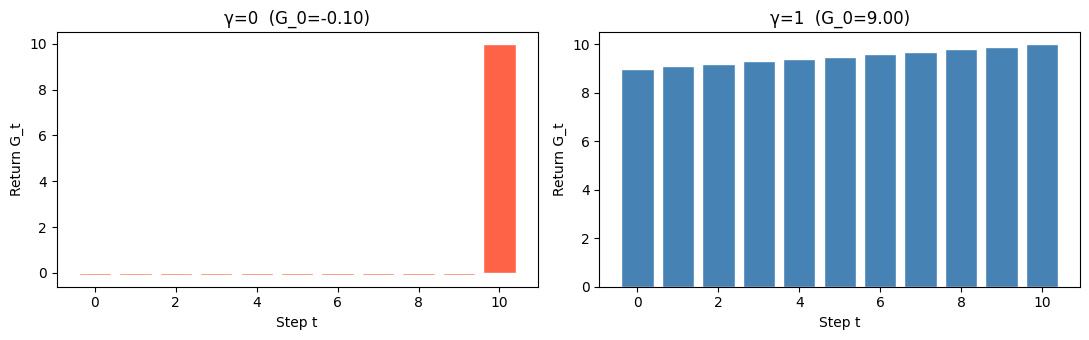

In [6]:
rewards_eg = [-0.1]*10 + [10.0]

G_gamma0  = compute_returns(rewards_eg, gamma=0.0)
G_gamma1  = compute_returns(rewards_eg, gamma=1.0)

print("γ=0: Only immediate reward matters.")
print(f"  G_0 = {G_gamma0[0]:.2f} (just the first reward: {rewards_eg[0]})")
print("  Creates a completely myopic agent — ignores all future rewards.")

print("\nγ=1: All future rewards weighted equally.")
print(f"  G_0 = {G_gamma1[0]:.2f} (sum of all rewards: {sum(rewards_eg):.1f})")
print("  Safe for episodic tasks (finite sum), but UNSAFE for continuing tasks")
print("  — the infinite sum may diverge if rewards don't shrink to 0.")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, (g, G, color) in zip(axes, [(0, G_gamma0, 'tomato'), (1, G_gamma1, 'steelblue')]):
    ax.bar(range(len(G)), G, color=color, edgecolor='white')
    ax.set_title(f'γ={g}  (G_0={G[0]:.2f})')
    ax.set_xlabel('Step t'); ax.set_ylabel('Return G_t')
plt.tight_layout(); plt.show()

γ where far reward (step 50) = 50% of G_0: γ ≈ 0.977
At that γ: far contribution = 31.56, G_0 = 61.58


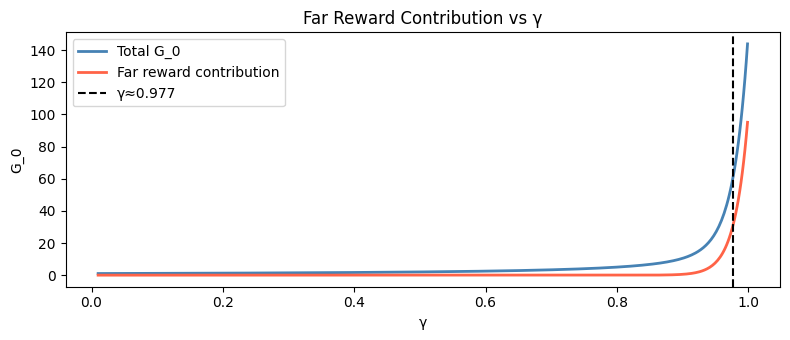

In [7]:
rewards_far = [1.0]*50 + [100.0]  # 100 arrives at step 50

gammas = np.linspace(0.01, 0.999, 500)
G0_values = [compute_returns(rewards_far, g)[0] for g in gammas]

# Far reward contribution = gamma^50 * 100
# Near reward contribution = sum of gamma^k * 1 for k=0..49
far_contributions  = [g**50 * 100 for g in gammas]
near_contributions = [compute_returns([1.0]*50, g)[0] for g in gammas]

# Find gamma where far reward >= 50% of total G_0
threshold_idx = np.argmax(np.array(far_contributions) >= np.array(G0_values) * 0.5)
gamma_threshold = gammas[threshold_idx]

print(f"γ where far reward (step 50) = 50% of G_0: γ ≈ {gamma_threshold:.3f}")
print(f"At that γ: far contribution = {far_contributions[threshold_idx]:.2f}, G_0 = {G0_values[threshold_idx]:.2f}")

plt.figure(figsize=(8, 3.5))
plt.plot(gammas, G0_values,         color='steelblue', linewidth=2, label='Total G_0')
plt.plot(gammas, far_contributions,  color='tomato',    linewidth=2, label='Far reward contribution')
plt.axvline(gamma_threshold, color='black', linestyle='--', label=f'γ≈{gamma_threshold:.3f}')
plt.xlabel('γ'); plt.ylabel('G_0'); plt.title('Far Reward Contribution vs γ')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
def compute_returns_forward(rewards, gamma):
    """
    Compute G_t = sum_{k=0}^{T-t-1} gamma^k * R_{t+k+1}
    without reversing the array — direct forward geometric series.
    """
    n = len(rewards)
    G = np.zeros(n)
    for t in range(n):
        # Remaining rewards from t onwards
        future = rewards[t:]
        powers = gamma ** np.arange(len(future))
        G[t] = np.dot(powers, future)
    return G

# Verify against backward method
rewards_test = np.random.randn(15)
gamma_test   = 0.9
G_backward = compute_returns(rewards_test, gamma_test)
G_forward  = compute_returns_forward(rewards_test, gamma_test)

assert np.allclose(G_backward, G_forward), "Mismatch!"
print("Forward and backward methods match")
print("Note: forward method is O(n²); backward is O(n) — backward preferred in practice.")

✅ Forward and backward methods match
Note: forward method is O(n²); backward is O(n) — backward preferred in practice.
